In [33]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps
import pymiediff as pmd
import time
# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

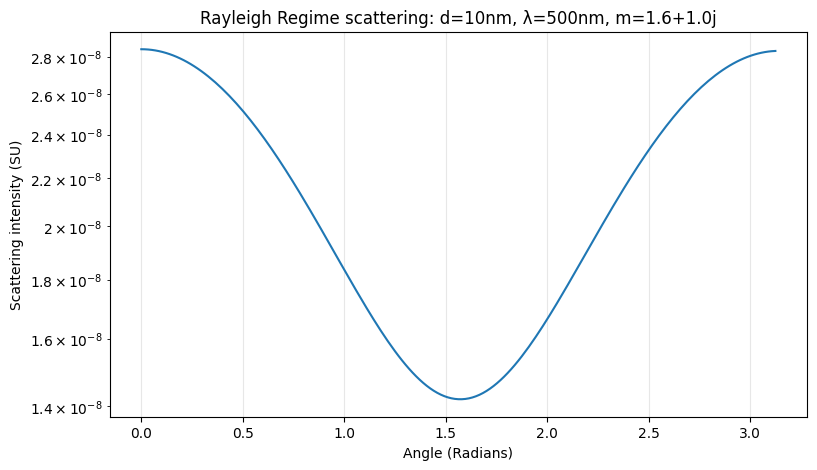

In [34]:
def py_Mie_Diff_Scattering(wavelength, diameter, n, k, environment_value = 1.00):
    # - setup the particle
    wl0 = torch.tensor([wavelength]) # converting into what pyMieDiff requires as input
    k0 = 2 * torch.pi / wl0

    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env = 1.00
    )

    theta = torch.arange(0, 181) * torch.pi/181
    
    angle_scattering = p.get_angular_scattering(k0= k0, theta = theta)
    return angle_scattering['i_unpol']

# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 10     # nm
theta = torch.arange(0, 181) * torch.pi/181

scattering = py_Mie_Diff_Scattering(wavelength, diameter, n, k)

plt.figure(figsize=(9, 5))
plt.plot(theta, scattering)
plt.xlabel("Angle (Radians)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Rayleigh Regime scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
N_PARTICLES = 900
N_ANGLES = 181
D_MIN = 600
D_MAX = 900
W_MIN = 450
W_MAX = 550
N_MIN = 1.0
N_MAX = 2.5
K_MIN = 0.001
K_MAX = 2.5 

X_MIN = np.pi * D_MIN/W_MAX
X_MAX = np.pi * D_MAX/W_MIN


# Particle-level storage: shape (N_PARTICLES, N_ANGLES, ...)
particle_inputs = np.zeros((N_PARTICLES, N_ANGLES, 4)) # 5 params
particle_outputs = np.zeros((N_PARTICLES, N_ANGLES))
    # Reserve 5 slots for derivatives: [n, k, wavelength, diameter (placeholder), theta]
particle_derivatives = np.zeros((N_PARTICLES, N_ANGLES, 4)) # full jacobian storage (diameter kept as placeholder)

# Takes 5 input values, diameter will be calculated using known wavelength
def compute_log_scattering(n_norm, k_norm, x_norm, theta_norm):

    # Un-normalize to physical values
    n = n_norm * (N_MAX - N_MIN) + N_MIN
    k = k_norm * (K_MAX - K_MIN) + K_MIN
    x = x_norm * (X_MAX - X_MIN) + X_MIN
    theta = theta_norm * torch.pi

    w = 500
    
    # determined using a known wavelength
    diameter = x * w / np.pi
    
    # rest is the same
    particle = pmd.Particle(
        r_layers=torch.stack([diameter / 2]),
        mat_layers=[n + 1j * k],
        mat_env=1.00
    )
    k0 = 2 * torch.pi / w
    scattering = particle.get_angular_scattering(k0=k0, theta=theta)
    return torch.log10(scattering['i_unpol'])

print("Particle setup complete.")
print(f"Storage allocated for {N_PARTICLES} particles × {N_ANGLES} angles × 5 params")


Particle setup complete.
Storage allocated for 900 particles × 181 angles × 5 params


Generating 900 particles with jacobians...
Particle 0 — n=1.28, k=0.70, λ=5.1
  particle 0/900  (1.2s elapsed)
Particle 1 — n=2.24, k=0.71, λ=4.3
Particle 2 — n=1.86, k=0.36, λ=5.2
Particle 3 — n=1.55, k=0.22, λ=5.4
Particle 4 — n=2.19, k=0.44, λ=5.3
Particle 5 — n=1.33, k=2.19, λ=4.0
Particle 6 — n=1.00, k=2.18, λ=4.4
Particle 7 — n=2.13, k=0.38, λ=4.6
Particle 8 — n=1.14, k=1.22, λ=4.4
Particle 9 — n=1.44, k=0.52, λ=3.5
  particle 25/900  (15.4s elapsed)
  particle 50/900  (30.8s elapsed)
  particle 75/900  (45.2s elapsed)
  particle 100/900  (59.6s elapsed)
  particle 125/900  (73.9s elapsed)
  particle 150/900  (88.6s elapsed)
  particle 175/900  (104.1s elapsed)
  particle 200/900  (118.9s elapsed)
  particle 225/900  (133.3s elapsed)
  particle 250/900  (147.5s elapsed)
  particle 275/900  (161.8s elapsed)
  particle 300/900  (176.0s elapsed)
  particle 325/900  (190.4s elapsed)
  particle 350/900  (205.4s elapsed)
  particle 375/900  (220.2s elapsed)
  particle 400/900  (234.9s 

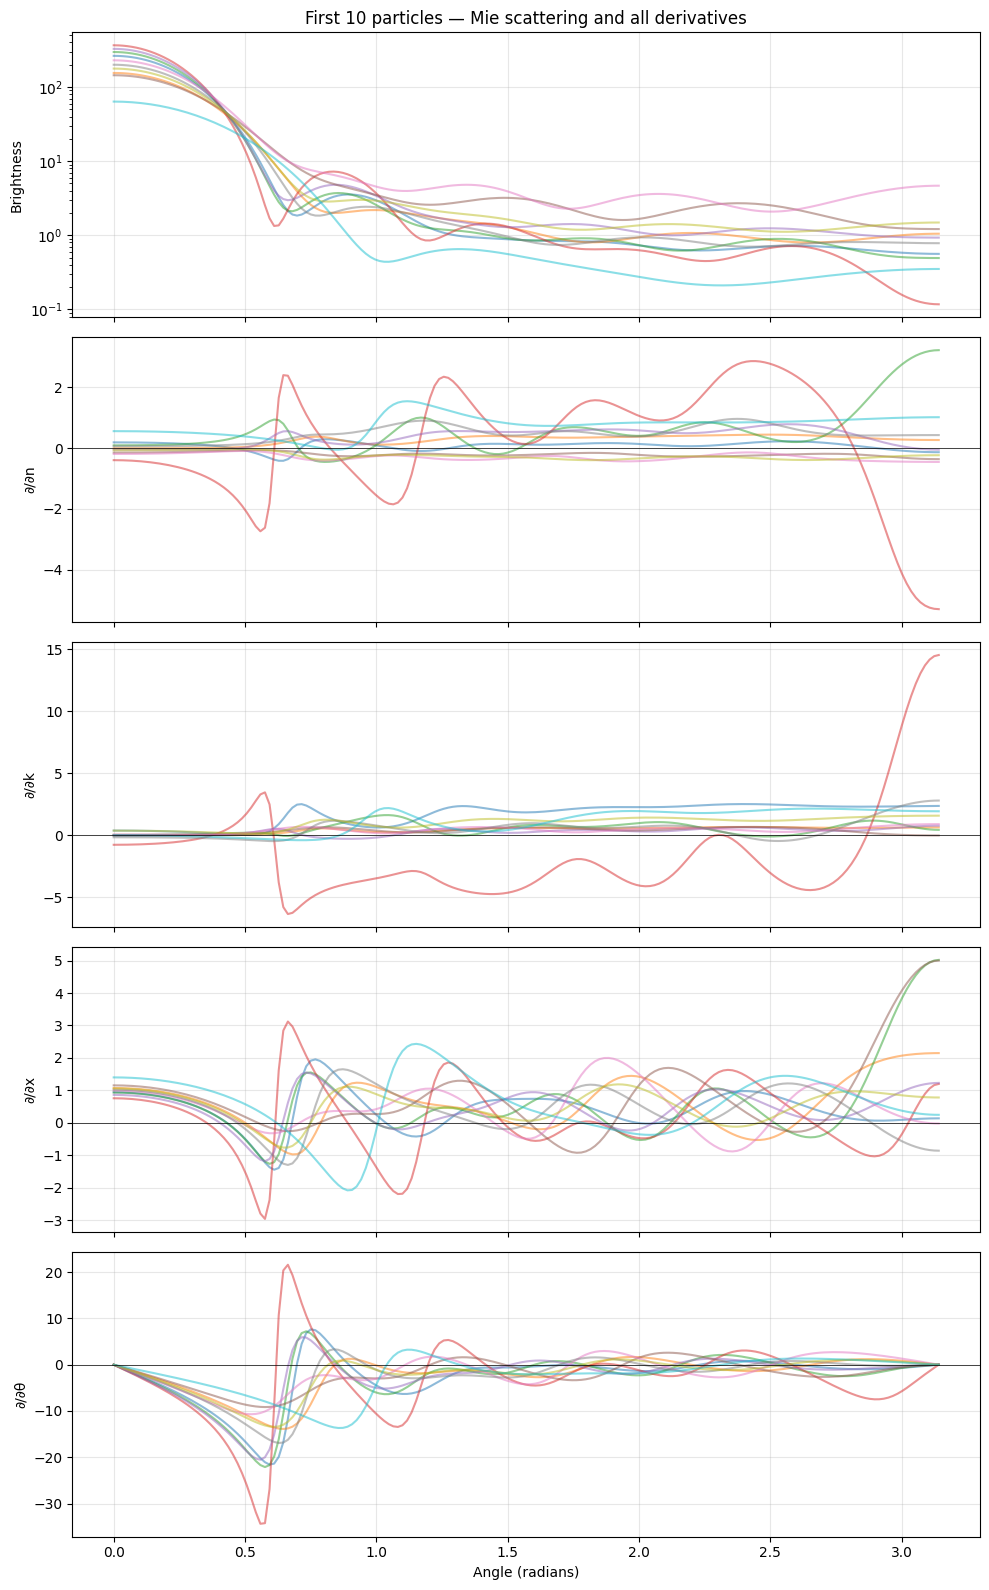


Saved to disk:
  inputs_4d.npy:      (162900, 4)
  outputs_4d.npy:     (162900, 1)
  derivatives_4d.npy: (162900, 4)


In [46]:
# helper normalization function
def normalize(value, value_min, value_max):
    return (value - value_min)/(value_max - value_min)


print(f"Generating {N_PARTICLES} particles with jacobians...")

fig, axes = plt.subplots(5, 1, figsize=(10, 16), sharex=True)

start_time = time.time()
for p in range(N_PARTICLES):

    # log space random sampling each parameter
    # wavelength = 10 ** torch.tensor(np.random.uniform(np.log10(W_MIN), np.log10(W_MAX)))
    wavelength = 10 ** torch.tensor(np.random.uniform(np.log10(W_MIN), np.log10(W_MAX)))
    # diameter   = 10 ** torch.tensor(np.random.uniform(np.log10(D_MIN), np.log10(D_MAX)))
    diameter   = 10 ** torch.tensor(np.random.uniform(np.log10(D_MIN), np.log10(D_MAX)))
    n          = torch.tensor(np.random.uniform(N_MIN, N_MAX))
    k          = torch.tensor(np.random.uniform(K_MIN, K_MAX))
    theta      = torch.tensor(np.linspace(0, np.pi, N_ANGLES))   # in radians, 0 to π inclusive

    # normalizing all parameters
    wavelength_norm = normalize(wavelength, W_MIN, W_MAX)
    diameter_norm   = normalize(diameter, D_MIN, D_MAX)
    n_norm          = normalize(n, N_MIN, N_MAX)
    k_norm          = normalize(k, K_MIN, K_MAX)
    theta_norm      = normalize(theta, 0, np.pi)
    
    # determining and normalizing x
    x       = 2 * np.pi*(diameter/2)/wavelength
    x_norm  = normalize(x, X_MIN, X_MAX)

    # Compute jacobian derivatives with autograd
    # jacobian wraps inputs with gradient tracking
    jacobian_derivative = torch.autograd.functional.jacobian(
        compute_log_scattering,
        (n_norm, k_norm, x_norm, theta_norm),
        vectorize=True,
        create_graph=True
    )

    # compute actual values without gradients for storage
    with torch.no_grad():
        log_scattering = compute_log_scattering(n_norm, k_norm, x_norm, theta_norm)
        scattering = 10 ** log_scattering
    
    # Store inputs
    particle_inputs[p, :, 0] = n
    particle_inputs[p, :, 1] = k
    particle_inputs[p, :, 2] = x
    particle_inputs[p, :, 3] = theta
    
    # Store outputs
    particle_outputs[p, :] = scattering.numpy()
    
    # Store derivatives
    particle_derivatives[p, :, 0] = jacobian_derivative[0].detach().numpy()           # delta scattering/delta n
    particle_derivatives[p, :, 1] = jacobian_derivative[1].detach().numpy()           # delta scattering/delta k
    particle_derivatives[p, :, 2] = jacobian_derivative[2].detach().numpy()           # delta scattering/delta x
    particle_derivatives[p, :, 3] = jacobian_derivative[3].diag().detach().numpy()    # delta scattering/delta theta (diagonal)
    
    
    if p < 10:
        # For the first 10 particles, plot the scattering and all derivatives
        print(f"Particle {p} — n={n:.2f}, k={k:.2f}, λ={x:.1f}")
        angles = theta_norm.numpy() * np.pi
        axes[0].plot(angles, scattering.numpy(), alpha=0.5)
        axes[1].plot(angles, jacobian_derivative[0].detach().numpy(), alpha=0.5)    # ∂brightness/∂n
        axes[2].plot(angles, jacobian_derivative[1].detach().numpy(), alpha=0.5)    # ∂brightness/∂k
        axes[3].plot(angles, jacobian_derivative[2].detach().numpy(), alpha=0.5)    # ∂brightness/∂x
        axes[4].plot(angles, jacobian_derivative[3].diag().detach().numpy(), alpha=0.5)   # ∂brightness/∂theta

    if p % 25 == 0:
        elapsed = time.time() - start_time
        print(f"  particle {p}/{N_PARTICLES}  ({elapsed:.1f}s elapsed)")

total_time = time.time() - start_time
print(f"\nDone! Total time: {total_time:.1f}s ({total_time/N_PARTICLES:.2f}s per particle)")

print(jacobian_derivative[3])

# After the loop:
axes[0].set_ylabel('Brightness')
axes[0].set_title('First 10 particles — Mie scattering and all derivatives')
axes[0].set_yscale('log')
axes[1].set_ylabel('∂/∂n')
axes[2].set_ylabel('∂/∂k')
axes[3].set_ylabel('∂/∂x')
axes[4].set_ylabel('∂/∂θ')
axes[4].set_xlabel('Angle (radians)')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Save data to disk so we don't regenerate
np.save('inputs_4d.npy', particle_inputs.reshape(-1, 4))
np.save('outputs_4d.npy', particle_outputs.reshape(-1, 1))
np.save('derivatives_4d.npy', particle_derivatives.reshape(-1, 4))

print("\nSaved to disk:")
print(f"  inputs_4d.npy:      {particle_inputs.reshape(-1, 4).shape}")
print(f"  outputs_4d.npy:     {particle_outputs.reshape(-1, 1).shape}")
print(f"  derivatives_4d.npy: {particle_derivatives.reshape(-1, 4).shape}")



In [47]:
print(f"x = {x.item():.3f}")
print(particle_inputs.shape)
print(particle_outputs.shape)
print(particle_derivatives.shape)

x = 5.566
(900, 181, 4)
(900, 181)
(900, 181, 4)


In [74]:
inputs_saved = np.load('inputs_4d.npy')           # (N, 5)
outputs_saved = np.load('outputs_4d.npy')         # (N, 1)
derivatives_saved = np.load('derivatives_4d.npy') # (N, 5)

#print the the first 10 inputs, outputs, and derivatives to verify they loaded correctly
print("First 10 loaded samples:")
# for i in range(10):
#     print(f"Sample {i}:")
#     print(f"  Input (n, k, wavelength, diameter, theta): {inputs_saved[i]}")
#     print(f"  Output (scattering): {outputs_saved[i]}")
#     print(f"  Derivatives (dn, dk, dx, dtheta): {derivatives_saved[i]}")
#     print()

N_SAMPLES = inputs_saved.shape[0]

print(f"Loaded {N_SAMPLES} training samples")

# flatten particle data for training
inputs = inputs_saved.reshape(-1, 4)         # (n_particles * angles, 5)
outputs = outputs_saved.reshape(-1, 1)       # (n_particles * angles, 1)
derivatives = derivatives_saved.reshape(-1, 4) # (n_particles * angles, 4)  ← changed: -1, 5
N_SAMPLES = inputs_saved.shape[0] # num of rows in inputs

# log transform the outputs
log_outputs = np.log10(outputs)

# normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   700-900 → (diameter - 700) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - N_MIN) / (N_MAX - N_MIN)                 # n
inputs_norm[:, 1] = (inputs[:, 1] - K_MIN) / (K_MAX - K_MIN)                       # k
inputs_norm[:, 2] = (inputs[:, 2] - X_MIN) / (X_MAX - X_MIN)     # x
inputs_norm[:, 3] = inputs[:, 3] / np.pi                         # angle

# train/test split 80 percent train, 20 percent test

particle_perm = np.random.permutation(N_PARTICLES)
particle_inputs = particle_inputs[particle_perm]
particle_outputs = particle_outputs[particle_perm]
particle_derivatives = particle_derivatives[particle_perm]

n_train = int(0.8 * N_SAMPLES)

X_train = torch.FloatTensor(inputs_norm[:n_train])
y_train = torch.FloatTensor(log_outputs[:n_train])
dy_train = torch.FloatTensor(derivatives[:n_train]) # for loss function

X_test = torch.FloatTensor(inputs_norm[n_train:])
y_test = torch.FloatTensor(log_outputs[n_train:])
dy_test = torch.FloatTensor(derivatives[n_train:])

print(f"Shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}, dy_train: {dy_train.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}, dy_test:  {dy_test.shape}")
print()
print(f"Sample input (normalized): {X_train[0]}")
print(f"Sample output (log): {y_train[0]}")
print(f"Sample derivative (truth): {dy_train[0]}")


First 10 loaded samples:
Loaded 162900 training samples
Shapes:
  X_train: torch.Size([130320, 4]), y_train: torch.Size([130320, 1]), dy_train: torch.Size([130320, 4])
  X_test:  torch.Size([32580, 4]), y_test:  torch.Size([32580, 1]), dy_test:  torch.Size([32580, 4])

Sample input (normalized): tensor([0.1853, 0.2786, 0.5970, 0.0000])
Sample output (log): tensor([2.4214])
Sample derivative (truth): tensor([0.1910, 0.3960, 0.9444, -0.0000])


In [75]:
model = nn.Sequential(
    nn.Linear(4, 128),       # input layer: 4 features to 128 neurons
    nn.GELU(),
    nn.Linear(128, 256),
    nn.GELU(),
    nn.Linear(256, 128),    # output layer: 256 to 256 (one per angle)
    nn.GELU(),
    nn.Linear(128,1)
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=128, out_features=256, bias=True)
  (3): GELU(approximate='none')
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 66689


In [76]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [ ]:
N_EPOCHS = 200
BATCH_SIZE = 128

train_losses = []
test_losses = []
n_train = X_train.shape[0]
n_batches = n_train // BATCH_SIZE

print(n_train)


# def determine_derivative()
print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")
training_start = time.time()

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    dy_shuffled = dy_train[perm] # shuffle the derivatives the same way

    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0

    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end].clone().requires_grad_(True) # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        dy_batch = dy_shuffled[start:end]

        # forward pass
        pred = model(X_batch)

        # take jacobian derivative of prediction wrt all 4 inputs
        nn_derivative = torch.autograd.grad(pred.sum(), (X_batch), create_graph=True)[0]

        
        loss_intensity = loss_fn(pred, y_batch) # get the loss for brightness

        # Compute SEPARATE loss terms for angle vs other derivatives
        loss_derivative_angle = loss_fn(
            nn_derivative[:, 3],     # NN's angle derivative
            dy_batch[:, 3]            # truth angle derivative
        )

        loss_derivative_x = loss_fn(
            nn_derivative[:, 2],
            dy_batch[:, 2]
        )
    
        

        loss_derivative_k = loss_fn(
            nn_derivative[:, [1]],
            dy_batch[:, [1]]
        )

        loss_derivative_n = loss_fn(
            nn_derivative[:, [0]],   # NN's n
            dy_batch[:, [0]]          # truth n 
        )

        # Combine with different weights
        loss = loss_intensity + 0.00 * loss_derivative_angle + 0.0 * loss_derivative_x + 0 * loss_derivative_k + 0 * loss_derivative_n
        
        # total loss is intensity loss + derivative loss (scaled down)

        # back propogate
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    

    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    X_test_req = X_test.detach().clone().requires_grad_(True) # this way the original X_test doesn't have to carry around it's claculation history
    test_pred = model(X_test_req) #predict on 200 test examples
    test_nn_derivative = torch.autograd.grad(test_pred.sum(), X_test_req, create_graph=False)[0] # derivative with respect to training parameters
    test_loss_intensity = loss_fn(test_pred, y_test).item() #compute MSE on test set
    


# Compute SEPARATE loss terms for angle vs other derivatives
    test_loss_derivative_angle = loss_fn(
        test_nn_derivative[:, 3],     # NN's angle derivative
        dy_test[:, 3]            # truth angle derivative
    ).item()

    test_loss_derivative_x = loss_fn(
        test_nn_derivative[:, 2],
        dy_test[:, 2]
    ).item()

    test_loss_derivative_k = loss_fn(
        test_nn_derivative[:, [1]],   # NN's k
        dy_test[:, [1]]          # truth k
    ).item()

    test_loss_derivative_n = loss_fn(
        test_nn_derivative[:, [0]],   # NN's n
        dy_test[:, [0]]          # truth n
    ).item()

    test_loss = test_loss_intensity + 0.00 * test_loss_derivative_angle + 0.0 * test_loss_derivative_x + 0 * test_loss_derivative_k + 0 * test_loss_derivative_n
    test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.2f}s")
print(f"Final loss: {train_losses[-1]:.6e}")
print("\nTraining complete!")

130320
Training: 200 epochs, 1018 batches per epoch

Epoch   0  Train Loss: 0.1870733861  Test Loss: 0.0480703935
Epoch  20  Train Loss: 0.0094084071  Test Loss: 0.0086536724
Epoch  40  Train Loss: 0.0067302390  Test Loss: 0.0066847955
Epoch  60  Train Loss: 0.0051789969  Test Loss: 0.0046157390
Epoch  80  Train Loss: 0.0041869753  Test Loss: 0.0041417321
Epoch 100  Train Loss: 0.0033886435  Test Loss: 0.0039362297
Epoch 120  Train Loss: 0.0028313807  Test Loss: 0.0032425807


In [ ]:
X_test_req = X_test.detach().clone().requires_grad_(True)
test_pred = model(X_test_req)
test_nn_derivative = torch.autograd.grad(test_pred.sum(), X_test_req, create_graph=False)[0]

li = loss_fn(test_pred, y_test).item()
lt = loss_fn(test_nn_derivative[:, 3], dy_test[:, 3]).item()
lx = loss_fn(test_nn_derivative[:, 2], dy_test[:, 2]).item()
lo = loss_fn(test_nn_derivative[:, [0,1]], dy_test[:, [0,1]]).item()

print(f"Intensity:    {li:.4f}   contributes {li:.4f}")
print(f"θ deriv:      {lt:.4f}   contributes {0.001*lt:.4f}")
print(f"x deriv:      {lx:.4f}   contributes {0.01*lx:.4f}")
print(f"n,k deriv:    {lo:.4f}   contributes {0.1*lo:.4f}")
print(f"Sum:                     {li + 0.001*lt + 0.01*lx + 0.1*lo:.4f}")

Intensity:    0.0188   contributes 0.0188
θ deriv:      21.8698   contributes 0.0219
x deriv:      1891.8617   contributes 18.9186
n,k deriv:    28.2470   contributes 2.8247
Sum:                     21.7840


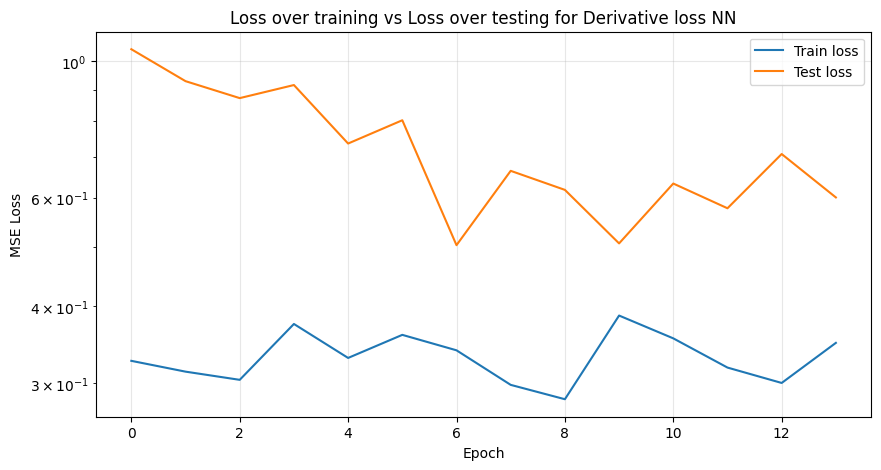

X_train shape: torch.Size([144800, 4])
y_train shape: torch.Size([144800, 1])
y_train min: -2.1103
y_train max: 5.7405
y_train mean: 0.5781
y_train variance: 0.9205

Final train loss: 0.3491
Final test loss: 0.6014


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing for Derivative loss NN")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_train min: {y_train.min().item():.4f}")
print(f"y_train max: {y_train.max().item():.4f}")
print(f"y_train mean: {y_train.mean().item():.4f}")
print(f"y_train variance: {y_train.var().item():.4f}")
print()
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss: {test_losses[-1]:.4f}")

Predicted log scattering shape: torch.Size([36200, 1])
Number of test particles: 200.0


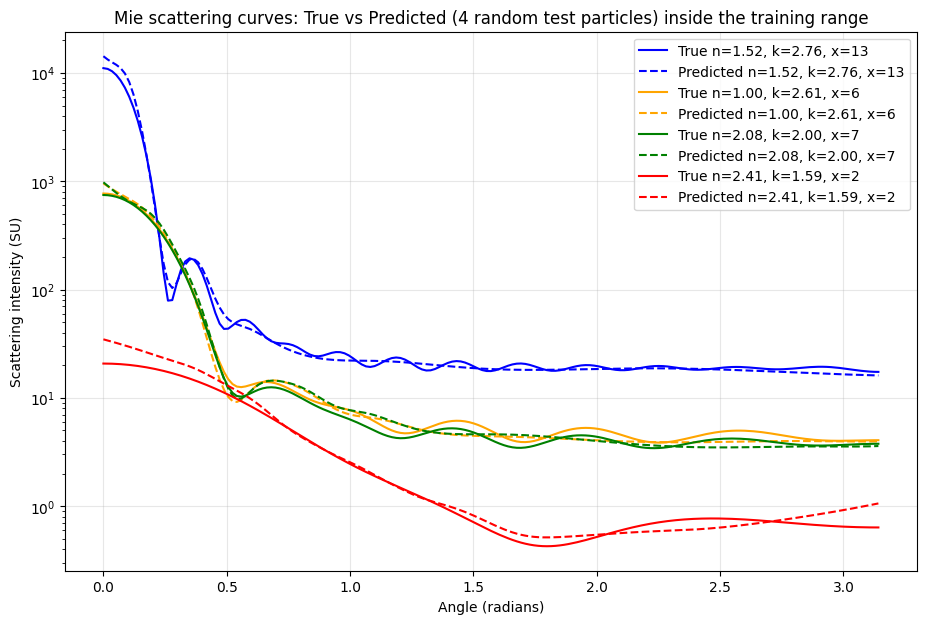

In [ ]:
# make some predictions
with torch.no_grad():
    test_pred = model(X_test)

n_test_particles = (X_test.shape[0])/181
print(f"Predicted log scattering shape: {test_pred.shape}")
print(f"Number of test particles: {n_test_particles}")

particle_indices = np.random.choice(int(n_test_particles), 4, replace = False)
colours = ['blue', 'orange', 'green', 'red']
plt.figure(figsize=(11, 7))

for p_id, color in zip(particle_indices, colours):
    start = int(p_id * 181)
    end = start + 181

    # convert back into 1D for graphing
    true_log_curve = y_test[start:end].numpy().flatten()
    pred_log_curve = test_pred[start:end].numpy().flatten()

    true_curve = 10 ** true_log_curve
    pred_curve = 10 ** pred_log_curve

    # unormalized inputs for title
    n = X_test[start, 0].item() * 2.5 + 1
    k = X_test[start, 1].item() * 3
    x = X_test[start, 2].item() * (X_MAX - X_MIN) + X_MIN
    theta = X_test[start:end, 3].numpy() * np.pi

    label = f"n={n:.2f}, k={k:.2f}, x={x:.0f}"
    plt.plot(theta, true_curve, label=f"True {label}", color=color, linestyle='-')
    plt.plot(theta, pred_curve, label=f"Predicted {label}", color=color, linestyle='--')

plt.xlabel("Angle (radians)")
plt.ylabel("Scattering intensity (SU)")
plt.title("Mie scattering curves: True vs Predicted (4 random test particles) inside the training range")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def predict_scattering(x, n, k, angle=None):
    if angle is None:
        angle = np.linspace(0, 180, 181) * np.pi / 180 # 181 angles from 0 to 180 degrees in radians
    angle = np.array(angle)

    # Normalize inputs
    x_norm = x
    n_norm = (n) / 2.0
    k_norm = (k) / 2.5
    theta_norm = angle / np.pi

    input_tensor = torch.FloatTensor([[n_norm, k_norm, wavelength_norm, diameter_norm, theta_norm[i]] for i in range(len(angle))])

    with torch.no_grad():
        log_pred = model(input_tensor)

    pred = 10 ** log_pred.numpy().flatten()
    return pred

# test wavelength and diameter
test_wavelength = 500
test_diameter = 900
test_n = 1.6
test_k = 1.0

print("Neural Network Prediction Time")
training_start = time.time()

nn_curve = predict_scattering(test_wavelength, test_diameter, test_n, test_k)

elapsed = time.time() - training_start
print(f"NN prediction time: {elapsed:.4f}s")

print("PyMieDiff Prediction Time")
training_start = time.time()
pmd_curve = py_Mie_Diff_Scattering(test_wavelength, test_diameter, test_n, test_k).numpy()
elapsed = time.time() - training_start
print(f"PyMieDiff prediction time: {elapsed:.4f}s")

# Calculate error
error = np.mean((np.log10(nn_curve) - np.log10(true_curve))**2)
print(f"Mean squared error (in log space): {error:.6e}")



true_curve_1 = py_Mie_Diff_Scattering(500, 500, 1.6, 1.0).numpy()
true_curve_2 = py_Mie_Diff_Scattering(500, 550, 1.6, 1.0).numpy()
true_curve_3 = py_Mie_Diff_Scattering(500, 950, 1.6, 1.0).numpy()
true_curve_4 = py_Mie_Diff_Scattering(500, 1000, 1.6, 1.0).numpy()

nn_curve_1 = predict_scattering(500, 500, 1.6, 1.0)
nn_curve_2 = predict_scattering(500, 550, 1.6, 1.0)
nn_curve_3 = predict_scattering(500, 950, 1.6, 1.0)
nn_curve_4 = predict_scattering(500, 1000, 1.6, 1.0)




angles = np.linspace(0, 180, 181) * np.pi / 180
plt.figure(figsize=(10, 6))

plt.plot(angles, true_curve_1, label='True d=500nm', color='red', linestyle='-')
plt.plot(angles, true_curve_2, label='True d=550nm', color='green', linestyle='-')
plt.plot(angles, true_curve_3, label='True d=950nm', color='blue', linestyle='-')
plt.plot(angles, true_curve_4, label='True d=1000nm', color='orange', linestyle='-')

plt.plot(angles, nn_curve_1, label='NN d=500nm', color='red', linestyle='--')
plt.plot(angles, nn_curve_2, label='NN d=550nm', color='green', linestyle='--')
plt.plot(angles, nn_curve_3, label='NN d=950nm', color='blue', linestyle='--')
plt.plot(angles, nn_curve_4, label='NN d=1000nm', color='orange', linestyle='--')

plt.xlabel("Angle (radians)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"NN vs PyMieDiff outside of training range (n=1.6, k=1.0, λ=500nm) with derivatives")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Neural Network Prediction Time


TypeError: len() of unsized object

In [ ]:
# creating 2D plot

N_D_SPANNING_DATA = 2000
n = 1.0
k = 1.79
fixed_lambda = 500

d_min = 50
d_max = 2000

d_span = np.logspace(np.log10(d_min), np.log10(d_max), N_D_SPANNING_DATA)
print("Computing Brightness for Each Diameter with PyMieDiff")
truth = np.zeros((N_D_SPANNING_DATA, 181)) # create array of 181 arrays which have values of 0

# generate the pyMieDiff curves for each diameter
for i, d in enumerate(d_span):
    curve = py_Mie_Diff_Scattering(fixed_lambda, d, n, k).numpy()
    truth[i, :] = curve

    if i % 100 == 0:
        print(f"  diameter {d:.1f}nm ({i}/{N_D_SPANNING_DATA})")


# generate the NN predictions for each diameter
print("Computing Brightness for Each Diameter with NN")

nn_pred = np.zeros((N_D_SPANNING_DATA, 181))

for id, d in enumerate(d_span):
    curve = predict_scattering(fixed_lambda, d, n, k)
    nn_pred[id, :] = curve

    if id % 100 == 0:
        print(f"  diameter {d:.1f}nm ({id}/{N_D_SPANNING_DATA})")

print(f"Diameter range: {d_span[0]:.0f} to {d_span[-1]:.0f} nm")
print(f"Training was: 300 to 1200 nm")

In [ ]:
log_truth = np.log10(truth)
log_nn = np.log10(nn_pred)

vmin = min(log_truth.min(), log_nn.min())
vmax = max(log_truth.max(), log_nn.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# PyMieDiff plot
im1 = axes[0].imshow(
    log_truth,
    aspect='auto',
    origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma',
    vmin=vmin, vmax=vmax
)
axes[0].set_title("PyMieDiff (truth)")
axes[0].set_xlabel("Angle (degrees)")
axes[0].set_ylabel("Diameter (nm)")
plt.colorbar(im1, ax=axes[0], label='log10(SU)')

# NN plot
im2 = axes[1].imshow(
    log_nn,
    aspect='auto',
    origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma',
    vmin=vmin, vmax=vmax
)
axes[1].set_title("NN prediction")
axes[1].set_xlabel("Angle (degrees)")
axes[1].set_ylabel("Diameter (nm)")
plt.colorbar(im2, ax=axes[1], label='log10(SU)')

# Mark training range boundaries
for ax in axes:
    ax.axhline(y=d_min, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=d_max, color='red', linestyle='--', linewidth=1)

plt.suptitle(f"NN with derivatives at λ={fixed_lambda}nm, n={n}, k={k}")
plt.tight_layout()
plt.show()

In [ ]:
import time

# Test parameters
n = 1.7
k = 0.85
wavelength = 500
diameter = 800

# Number of times to repeat each test (for averaging)
N_RUNS = 10

# Lists to store times
nn_times = []
pymiescatt_times = []
pymiediff_times = []

print(f"Running benchmark with {N_RUNS} repetitions per method...\n")

for run in range(N_RUNS):
    # --- Time NN prediction ---
    start = time.time()
    _ = predict_scattering(wavelength, diameter, n, k)
    nn_times.append(time.time() - start)
    
    # --- Time PyMieScatt ---
    start = time.time()
    m = complex(n, k)
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    pymiescatt_times.append(time.time() - start)
    
    # --- Time pyMieDiff ---
    start = time.time()
    wl0 = torch.tensor([float(wavelength)])
    k0 = 2 * torch.pi / wl0
    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env=1.00
    )

    theta_t = torch.arange(0, 181) * torch.pi/181
    angle_scattering = p.get_angular_scattering(k0=k0, theta=theta_t)
    pymiediff_times.append(time.time() - start)
    
    print(f"Run {run+1}/{N_RUNS}: NN={nn_times[-1]*1000:.2f}ms  PyMieScatt={pymiescatt_times[-1]*1000:.2f}ms  pyMieDiff={pymiediff_times[-1]*1000:.2f}ms")

# Summary stats
print(f"\n--- Average times ---")
print(f"NN:         {np.mean(nn_times)*1000:.2f} ms (±{np.std(nn_times)*1000:.2f} ms)")
print(f"PyMieScatt: {np.mean(pymiescatt_times)*1000:.2f} ms (±{np.std(pymiescatt_times)*1000:.2f} ms)")
print(f"pyMieDiff:  {np.mean(pymiediff_times)*1000:.2f} ms (±{np.std(pymiediff_times)*1000:.2f} ms)")

# Plot
fig, axes = plt.subplots(figsize=(7, 5))

# Left: time series of each run
axes.plot(range(1, N_RUNS+1), [t*1000 for t in nn_times], label='NN', color='blue')
axes.plot(range(1, N_RUNS+1), [t*1000 for t in pymiescatt_times], label='PyMieScatt', color='red')
axes.plot(range(1, N_RUNS+1), [t*1000 for t in pymiediff_times], label='pyMieDiff', color='green')
axes.set_xlabel('Run number')
axes.set_ylabel('Time (ms)')
axes.set_title('Per-run computation times')
axes.set_yscale('log')
axes.legend()
axes.grid(True, alpha=0.3)

plt.show()

In [ ]:
test_mse = ((model(X_test) - y_test) ** 2).mean().item()
print(f"Final MSE on test set: {test_mse:.8f}")

In [ ]:
print(X_train.shape)

In [ ]:
import matplotlib.pyplot as plt

model_names = ['BD 1.0', 'BD 1.1', 'BD 1.2', 'AD 1.0', 'AD 1.1']   # name your models
time_data = [0.12, 0.14, 0.42, 0.36, 0.45]
mse_data = [0.00003896, 0.000178, 0.00000522, 0.00000267, 0.00000153]
colors = ['tab:blue', 'tab:red', 'tab:olive', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time plot
for i, name in enumerate(model_names):
    axes[0].scatter(i, time_data[i], c=colors[i], s=150, label=name)
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names)
axes[0].set_ylabel('Time per prediction (ms)')
axes[0].set_title('Computation time')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# MSE plot
for i, name in enumerate(model_names):
    axes[1].scatter(i, mse_data[i], c=colors[i], s=150, label=name)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel('Test MSE')
axes[1].set_title('Prediction accuracy')
axes[1].set_yscale('log')   # log scale because values span 5 orders of magnitude
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()



In [ ]:
import time

# Test parameters
n = 1.7
k = 0.85
wavelength = 500
diameter = 800

# Number of times to repeat each test (for averaging)
N_RUNS = 10

# Lists to store times
nn_times = []
pymiescatt_times = []
pymiediff_times = []

print(f"Running benchmark with {N_RUNS} repetitions per method...\n")

for run in range(N_RUNS):
    
    # --- Time PyMieScatt ---
    start = time.time()
    m = complex(n, k)
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    pymiescatt_times.append(time.time() - start)
    
    # --- Time pyMieDiff ---
    start = time.time()
    wl0 = torch.tensor([float(wavelength)])
    k0 = 2 * torch.pi / wl0
    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env=1.00
    )

    theta_t = torch.arange(0, 181) * torch.pi/181
    angle_scattering = p.get_angular_scattering(k0=k0, theta=theta_t)
    pymiediff_times.append(time.time() - start)
    
    print(f"Run {run+1}/{N_RUNS}: PyMieScatt={pymiescatt_times[-1]*1000:.2f}ms  pyMieDiff={pymiediff_times[-1]*1000:.2f}ms")

# Summary stats
print(f"\n--- Average times ---")
print(f"PyMieScatt: {np.mean(pymiescatt_times)*1000:.2f} ms (±{np.std(pymiescatt_times)*1000:.2f} ms)")
print(f"pyMieDiff:  {np.mean(pymiediff_times)*1000:.2f} ms (±{np.std(pymiediff_times)*1000:.2f} ms)")

# Plot
fig, axes = plt.subplots(figsize=(7, 5))

# Left: time series of each run
# axes.plot(range(1, N_RUNS+1), [t*1000 for t in nn_times], label='NN', color='blue')
axes.plot(range(1, N_RUNS+1), [t*1000 for t in pymiescatt_times], label='PyMieScatt', color='red')
axes.plot(range(1, N_RUNS+1), [t*1000 for t in pymiediff_times], label='pyMieDiff', color='green')
axes.set_xlabel('Run number')
axes.set_ylabel('Time (ms)')
axes.set_title('Per-run computation times')
axes.set_yscale('log')
axes.legend()
axes.grid(True, alpha=0.3)

plt.show()

In [ ]:
result = predict_scattering(wavelength=500, diameter=800, n=1.7, k=0.85)
print(f"Result shape: {result.shape}")
print(f"First 5 values: {result[:5]}")
print(f"Last 5 values: {result[-5:]}")